In [82]:
import numpy as np
import pandas as pd


In [83]:
df = pd.read_csv("train.csv")

In [84]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [85]:
df.drop(["PassengerId","Name","Ticket"],axis=1,inplace=True)

In [86]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,0,3,male,22.0,1,0,7.2500,NaN,S
1,1,1,female,38.0,1,0,71.2833,C85,C
2,1,3,female,26.0,0,0,7.9250,NaN,S
3,1,1,female,35.0,1,0,53.1000,C123,S
4,0,3,male,35.0,0,0,8.0500,NaN,S


In [87]:
# check Dtypes:
dtypes=df.dtypes
dtypes

n_unique = df.nunique()
n_unique

pd.DataFrame({"Dtype":dtypes,"Num_unique":n_unique}).T


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
Dtype,int64,int64,str,float64,int64,int64,float64,str,str
Num_unique,2,3,2,88,7,7,248,147,3


In [88]:
# def chk_types(df):
#     dtypes=df.dtypes
#     n_unique = df.nunique()
#     return  pd.DataFrame({"Dtype":dtypes,"Num_unique":n_unique}).T


In [89]:
# chk_types(df)

In [90]:
from chk_t import check_type
check_type(df)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
Dtype,int64,int64,str,float64,int64,int64,float64,str,str
num_unique,2,3,2,88,7,7,248,147,3


In [91]:
cols = ['Survived','Pclass','Sex','SibSp','Parch','Embarked']
df[cols]=df[cols].astype("category")


In [92]:
from chk_t import check_type
check_type(df)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
Dtype,category,category,category,float64,category,category,float64,str,category
num_unique,2,3,2,88,7,7,248,147,3


In [93]:
def handle_types(cols):
    df[cols]=df[cols].astype("category") 
    check_type(df)

In [94]:
# Check Nulls:
null =df.isnull().sum()
ratio = null/df.shape[0]   # df.shape[0]=> Num of Rows
ratio
pd.DataFrame({"Null":null,"Ratio":ratio}).T


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
Null,0.0,0.0,0.0,177.000000,0.0,0.0,0.0,687.000000,2.000000
Ratio,0.0,0.0,0.0,0.198653,0.0,0.0,0.0,0.771044,0.002245


In [95]:
df = df.drop('Cabin',axis=1)

In [96]:
df = df.dropna(subset=['Embarked'])

In [97]:
median = df['Age'].median()
df['Age'] = df['Age'].fillna(median)

In [98]:
# Check Nulls:
null =df.isnull().sum()
ratio = null/df.shape[0]   # df.shape[0]=> Num of Rows
ratio
pd.DataFrame({"Null":null,"Ratio":ratio}).T


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
Null,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Ratio,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [99]:
import matplotlib.pyplot as plt
import seaborn as sns


In [100]:
df.dtypes

Survived    category
Pclass      category
Sex         category
Age          float64
SibSp       category
Parch       category
Fare         float64
Embarked    category
dtype: object

In [101]:
num_cols = ["Age","Fare"]

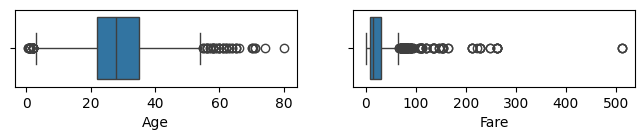

In [102]:
# To Find Outliers:
num_cols = df.select_dtypes("number").columns
plt.figure(figsize=(8,1))
for i , col in enumerate(num_cols):
    plt.subplot(1,2,i+1)
    sns.boxplot(df[col],orient="h")

In [116]:
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    Lower_Fence = Q1 - 1.5 * IQR
    Upper_Fence = Q3 + 1.5 * IQR
    
    Lower_Outliers = df[df[col] < Lower_Fence][col].values
    Upper_Outliers = df[df[col] > Upper_Fence][col].values
    
    df[col] = df[col].replace(Lower_Outliers,Lower_Fence,inplace=True)
    df[col] = df[col].replace(Upper_Outliers,Upper_Fence,inplace=True)

C:\Users\arbs\AppData\Local\Temp\ipykernel_1996\1690813355.py:12: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df[col] = df[col].replace(Lower_Outliers,Lower_Fence,inplace=True)
C:\Users\arbs\AppData\Local\Temp\ipykernel_1996\1690813355.py:13: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through ch

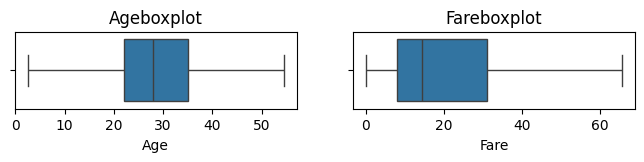

In [119]:
num_cols = df.select_dtypes("number").columns
plt.figure(figsize=(8,1))
for i , col in enumerate(num_cols):
    plt.subplot(1,2,i+1)
    sns.boxplot(df[col],orient="h")
    plt.title(f"{col}boxplot")
plt.show()

In [121]:
# Duplicate
df.duplicated().sum()

np.int64(129)

In [122]:
df.drop_duplicates(inplace=True)

In [124]:
df.duplicated().sum()

np.int64(0)

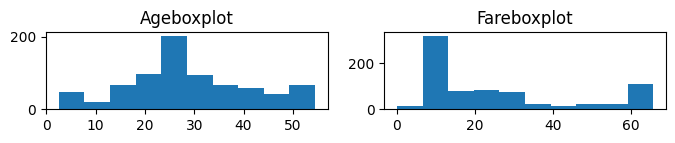

In [125]:
num_cols = df.select_dtypes("number").columns
plt.figure(figsize=(8,1))
for i , col in enumerate(num_cols):
    plt.subplot(1,2,i+1)
    plt.hist(df[col])
    plt.title(f"{col}boxplot")
plt.show()

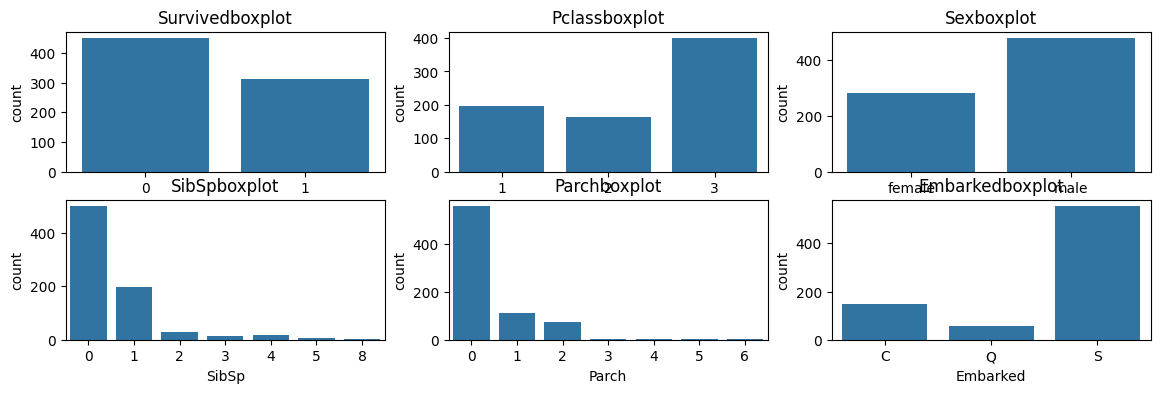

In [128]:
cat_cols = df.select_dtypes("category").columns
plt.figure(figsize=(14,4))
for i , col in enumerate(cat_cols):
    plt.subplot(2,3,i+1)
    sns.countplot(x = col,data = df)
    plt.title(f"{col}boxplot")
plt.show()